In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import scipy.stats as stats

In [4]:
df=pd.read_table('Fig4e.txt')
df

,Sample,Replicate,PP2A,BOR1
0,F3-2,1,1902.0,1185.2
1,F3-2,2,1687.7,918.4
2,F3-2,3,1178.8,682.5
3,F3-2,4,1438.4,796.9
4,F13-8,1,548.1,607.7
5,F13-8,2,1922.2,2303.5
6,F13-8,3,2653.6,3508.8


In [5]:
df['Ratio'] = df['BOR1']/df['PP2A']
df

,Sample,Replicate,PP2A,BOR1,Ratio
0,F3-2,1,1902.0,1185.2,0.623134
1,F3-2,2,1687.7,918.4,0.544173
2,F3-2,3,1178.8,682.5,0.578979
3,F3-2,4,1438.4,796.9,0.554018
4,F13-8,1,548.1,607.7,1.108739
5,F13-8,2,1922.2,2303.5,1.198366
6,F13-8,3,2653.6,3508.8,1.322279


In [8]:
Ratio_Control=df.loc[(df['Sample'] == 'F3-2')].Ratio.median()
print(Ratio_Control)

0.5664984880270767


In [9]:
df['Ratio_N']=df['Ratio']/Ratio_Control
df

,Sample,Replicate,PP2A,BOR1,Ratio,Ratio_N
0,F3-2,1,1902.0,1185.2,0.623134,1.099974
1,F3-2,2,1687.7,918.4,0.544173,0.960590
2,F3-2,3,1178.8,682.5,0.578979,1.022030
3,F3-2,4,1438.4,796.9,0.554018,0.977970
4,F13-8,1,548.1,607.7,1.108739,1.957180
5,F13-8,2,1922.2,2303.5,1.198366,2.115392
6,F13-8,3,2653.6,3508.8,1.322279,2.334127


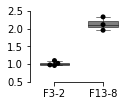

In [11]:
boxprops = {'edgecolor': 'black', 'linewidth': 0.5, 'facecolor': 'grey'}
lineprops = {'color': 'k', 'linewidth': 0.5}
boxplot_kwargs = dict({'boxprops': boxprops, 'medianprops': lineprops,
                       'whiskerprops': lineprops, 'capprops': lineprops,
                       'width': 0.6})
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
cm=1/2.54
fig, axes = plt.subplots(figsize=(5*cm,4*cm))
sns.boxplot(x='Sample',
        y='Ratio_N',
        data=df,
        color = 'grey',
        **boxplot_kwargs)
sns.swarmplot(x='Sample',
        y='Ratio_N',
        data=df,
        dodge=True,
        color = 'k') 
axes.set_xlabel('')
axes.set_ylabel('')
plt.ylim(0.5,2.5)
sns.despine(trim= True)
plt.tight_layout()
plt.savefig("Fig4e.pdf", format="pdf",bbox_inches="tight",facecolor="w")